In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("26-customer_data.csv")

In [3]:
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


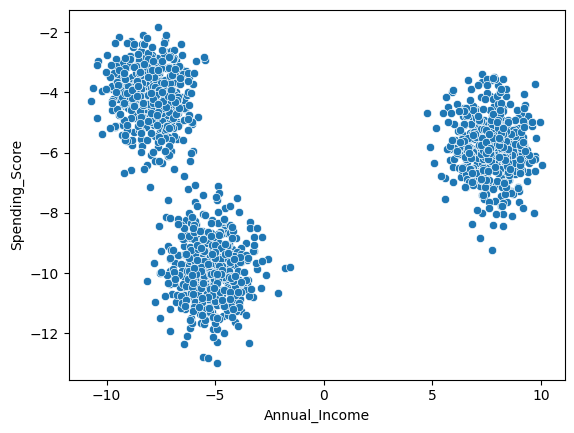

In [4]:
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=15)

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [17]:
#Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(init="k-means++", n_clusters=k)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

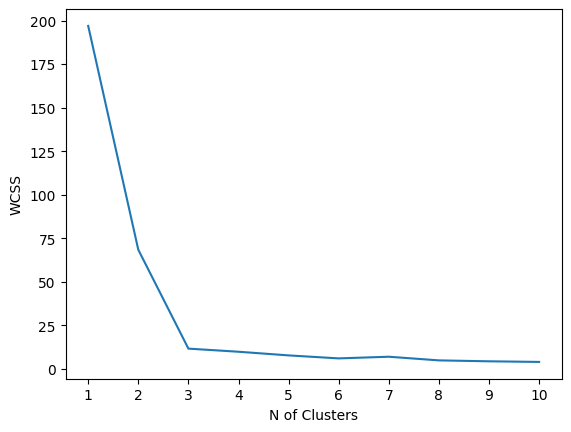

In [20]:
plt.plot(range(1, 11), wcss)
plt.xlabel("N of Clusters")
plt.xticks(range(1, 11))
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=3, init="k-means++")
kmeans.fit(X_train_scaled)
y_pred = kmeans.predict(X_test_scaled)

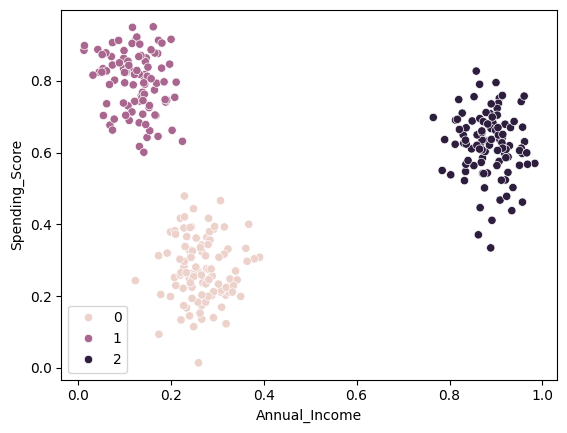

In [23]:
sns.scatterplot(data=pd.DataFrame(X_test_scaled, columns=X_test.columns), x="Annual_Income", y="Spending_Score", hue=y_pred)
plt.show()

In [24]:
from kneed import KneeLocator

In [25]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [26]:
kl.elbow

np.int64(3)

In [27]:
#silhoutte score

In [28]:
from sklearn.metrics import silhouette_score

In [29]:
silhoutte_scores = []

for k in range(2, 11):
    kmeans = KMeans(init="k-means++", n_clusters=k)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhoutte_scores.append(score) 

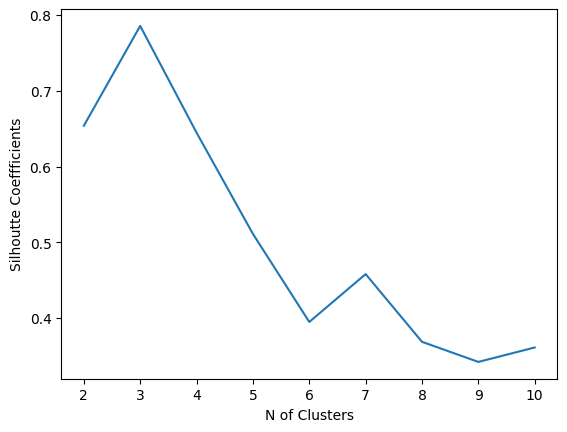

In [30]:
plt.plot(range(2, 11), silhoutte_scores)
plt.xlabel("N of Clusters")
plt.xticks(range(2, 11))
plt.ylabel("Silhoutte Coeffficients")
plt.show()